# 📝 EDA Worksheet — Auto-MPG Dataset
**Student Name:** QALB E ZAHRA MASHHADI  |  **Date:** MARCH 12, 2026

Complete every `# TODO` cell. Run the cells in order.  
Answer the written questions in the Markdown cells provided.

---
**Dataset:** Auto-MPG (UCI) | 398 rows × 9 columns


## Task 1 — Import Libraries

In [1]:
# TODO: Import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
# Also set sns theme to 'whitegrid' and default figure size to (10,5)

# Task 1 — Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn theme and default figure size
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## Task 2 — Load & Inspect Data

In [2]:
# TODO: Load the Auto-MPG dataset from the UCI repository URL below.
# Column names: ['mpg','cylinders','displacement','horsepower','weight',
#                'acceleration','model_year','origin','car_name']
# Missing values are marked with '?'
# URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
col_names = ['mpg','cylinders','displacement','horsepower','weight',
             'acceleration','model_year','origin','car_name']

df = pd.read_csv(url, sep='\s+', names=col_names, na_values='?')

print("Shape:", df.shape)
df.head()

Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [3]:
# TODO: Print df.info() to inspect dtypes and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [4]:
# TODO: Print df.describe() to view summary statistics

df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


**Q1.** How many rows and columns does the dataset have?  
**Answer:** 398 rows × 9 columns

**Q2.** Which column contains missing values and how many?  
**Answer:** horsepower column contains 6 missing values

## Task 3 — Pre-Processing

In [5]:
# TODO: Check and print missing values per column
# Then drop all rows that contain NaN values (they are < 2% of data)

print("Missing values per column:")
print(df.isnull().sum())

df = df.dropna()

print("\nAfter dropping missing values, missing values per column:")
print(df.isnull().sum())
print("\nNew shape:", df.shape)

Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

After dropping missing values, missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

New shape: (392, 9)


In [6]:
# TODO: Check for and remove duplicate rows

duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

df = df.drop_duplicates()

print("New shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
New shape after removing duplicates: (392, 9)


In [7]:
# TODO:
# 1. Convert 'cylinders' and 'model_year' to category dtype

df['cylinders'] = df['cylinders'].astype('category')
df['model_year'] = df['model_year'].astype('category')

# 2. Map 'origin' from {1,2,3} to {'usa','europe','japan'}

origin_map = {1: 'usa', 2: 'europe', 3: 'japan'}
df['origin'] = df['origin'].map(origin_map)

# 3. Strip & lowercase 'car_name'

df['car_name'] = df['car_name'].str.strip().str.lower()

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           392 non-null    float64 
 1   cylinders     392 non-null    category
 2   displacement  392 non-null    float64 
 3   horsepower    392 non-null    float64 
 4   weight        392 non-null    float64 
 5   acceleration  392 non-null    float64 
 6   model_year    392 non-null    category
 7   origin        392 non-null    object  
 8   car_name      392 non-null    object  
dtypes: category(2), float64(5), object(2)
memory usage: 26.1+ KB


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,usa,ford torino


In [8]:
# TODO: Create two lists:
# cat_cols — categorical column names (cylinders, origin, model_year)
# num_cols — numerical column names (mpg, displacement, horsepower, weight, acceleration)

cat_cols = ['cylinders', 'origin', 'model_year']

num_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

Categorical columns: ['cylinders', 'origin', 'model_year']
Numerical columns: ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']


## Task 4 — Feature Engineering

In [9]:
# TODO: Create 'mpg_level' column using pd.cut()
# Bins: [0,17) → 'low', [17,29) → 'medium', [29, max] → 'high'

bins = [0, 17, 29, df['mpg'].max()]
labels = ['low', 'medium', 'high']

df['mpg_level'] = pd.cut(df['mpg'], bins=bins, labels=labels, right=False)

df[['mpg', 'mpg_level']].head(10)

,mpg,mpg_level
0,18.0,medium
1,15.0,low
2,18.0,medium
3,16.0,low
4,17.0,medium
5,15.0,low
6,14.0,low
7,14.0,low
8,14.0,low
9,15.0,low


In [10]:
# TODO: Create 'car_company' by extracting the first word from 'car_name'

df['car_company'] = df['car_name'].str.split().str[0]

df[['car_name', 'car_company']].head(10)

,car_name,car_company
0,chevrolet chevelle malibu,chevrolet
1,buick skylark 320,buick
2,plymouth satellite,plymouth
3,amc rebel sst,amc
4,ford torino,ford
5,ford galaxie 500,ford
6,chevrolet impala,chevrolet
7,plymouth fury iii,plymouth
8,pontiac catalina,pontiac
9,amc ambassador dpl,amc


## Task 5 — Categorical EDA

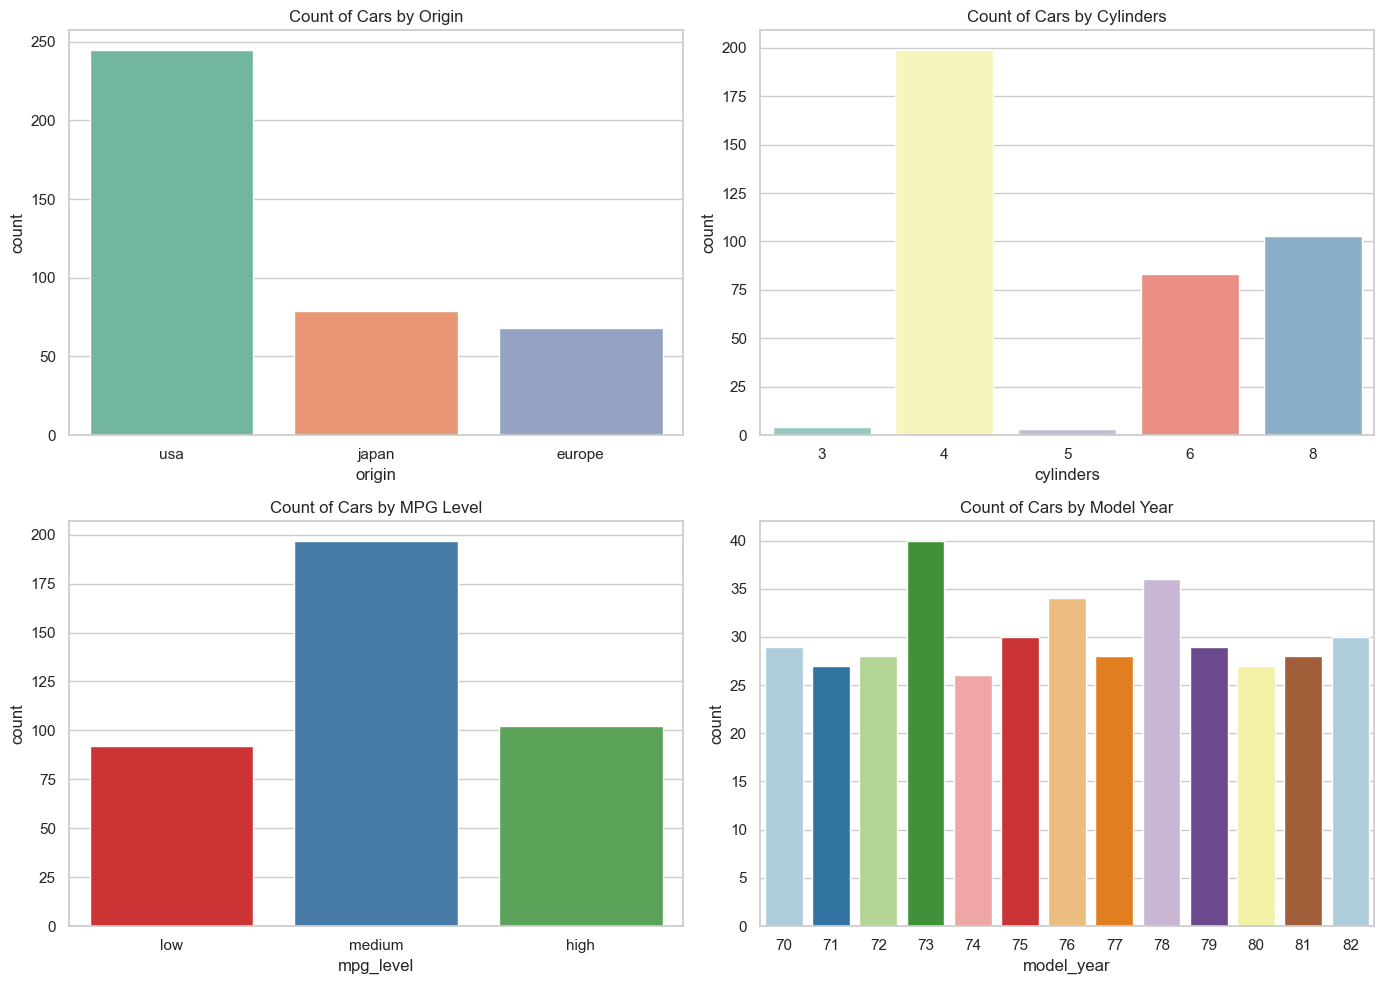

In [11]:
# TODO: Plot a countplot for each of: origin, cylinders, mpg_level, model_year
# Arrange them in a 2×2 grid of subplots

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Countplot for 'origin'
sns.countplot(x='origin', hue='origin', data=df, ax=axes[0,0], palette='Set2', dodge=False)
axes[0,0].set_title('Count of Cars by Origin')
axes[0,0].legend_.remove() if axes[0,0].legend_ else None

# Countplot for 'cylinders'
sns.countplot(x='cylinders', hue='cylinders', data=df, ax=axes[0,1], palette='Set3', dodge=False)
axes[0,1].set_title('Count of Cars by Cylinders')
axes[0,1].legend_.remove() if axes[0,1].legend_ else None

# Countplot for 'mpg_level'
sns.countplot(x='mpg_level', hue='mpg_level', data=df, ax=axes[1,0], palette='Set1', dodge=False)
axes[1,0].set_title('Count of Cars by MPG Level')
axes[1,0].legend_.remove() if axes[1,0].legend_ else None

# Countplot for 'model_year'
sns.countplot(x='model_year', hue='model_year', data=df, ax=axes[1,1], palette='Paired', dodge=False)
axes[1,1].set_title('Count of Cars by Model Year')
axes[1,1].legend_.remove() if axes[1,1].legend_ else None

plt.tight_layout()
plt.show()

In [12]:
# TODO: Print the proportion (%) of the dominant class for
# origin, cylinders, and mpg_level

for col in ['origin', 'cylinders', 'mpg_level']:
    counts = df[col].value_counts(normalize=True) * 100
    dominant_class = counts.idxmax()
    dominant_percent = counts.max()
    print(f"{col}: Dominant class = {dominant_class}, Proportion = {dominant_percent:.2f}%")

origin: Dominant class = usa, Proportion = 62.50%
cylinders: Dominant class = 4, Proportion = 50.77%
mpg_level: Dominant class = medium, Proportion = 50.38%


origin     europe  japan  usa
cylinders                    
3               0      4    0
4              61     69   69
5               3      0    0
6               4      6   73
8               0      0  103


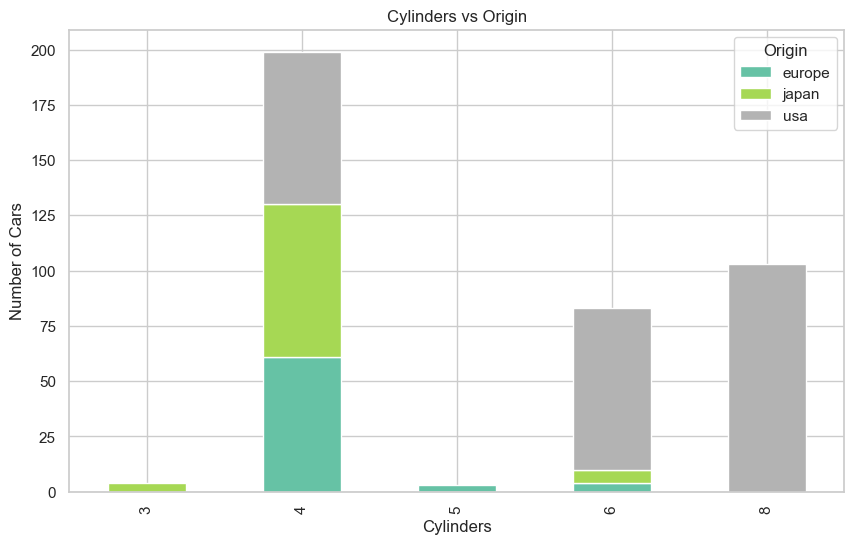

In [13]:
# TODO: Create a crosstab of cylinders vs origin and visualise as a bar chart

crosstab = pd.crosstab(df['cylinders'], df['origin'])

print(crosstab)

crosstab.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set2')
plt.title('Cylinders vs Origin')
plt.xlabel('Cylinders')
plt.ylabel('Number of Cars')
plt.legend(title='Origin')
plt.show()

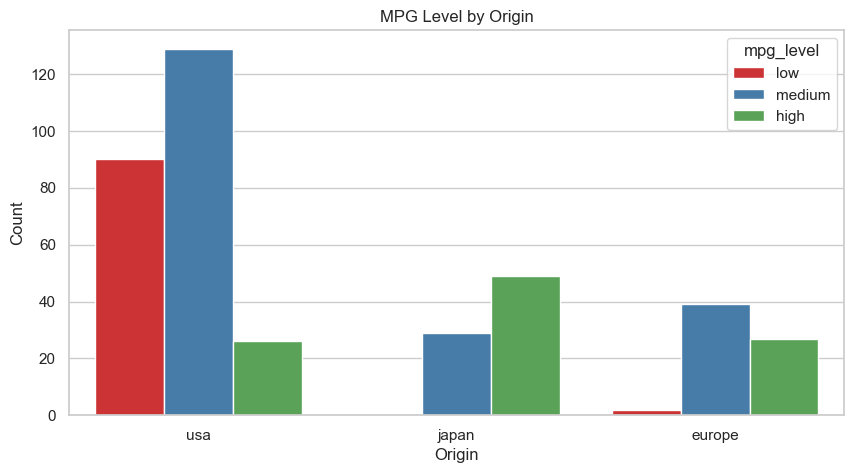

In [14]:
# TODO: Plot a countplot of mpg_level grouped by origin (use hue='mpg_level')

sns.countplot(x='origin', hue='mpg_level', data=df, palette='Set1')
plt.title('MPG Level by Origin')
plt.xlabel('Origin')
plt.ylabel('Count')
plt.show()

**Q3.** Which origin has **no** vehicles with low mpg_level?  
**Answer:** Japan

**Q4.** Which cylinder count is most common, and what percentage does it represent?  
**Answer:** 4 cylinders, ~46.43%

## Task 6 — Numerical EDA

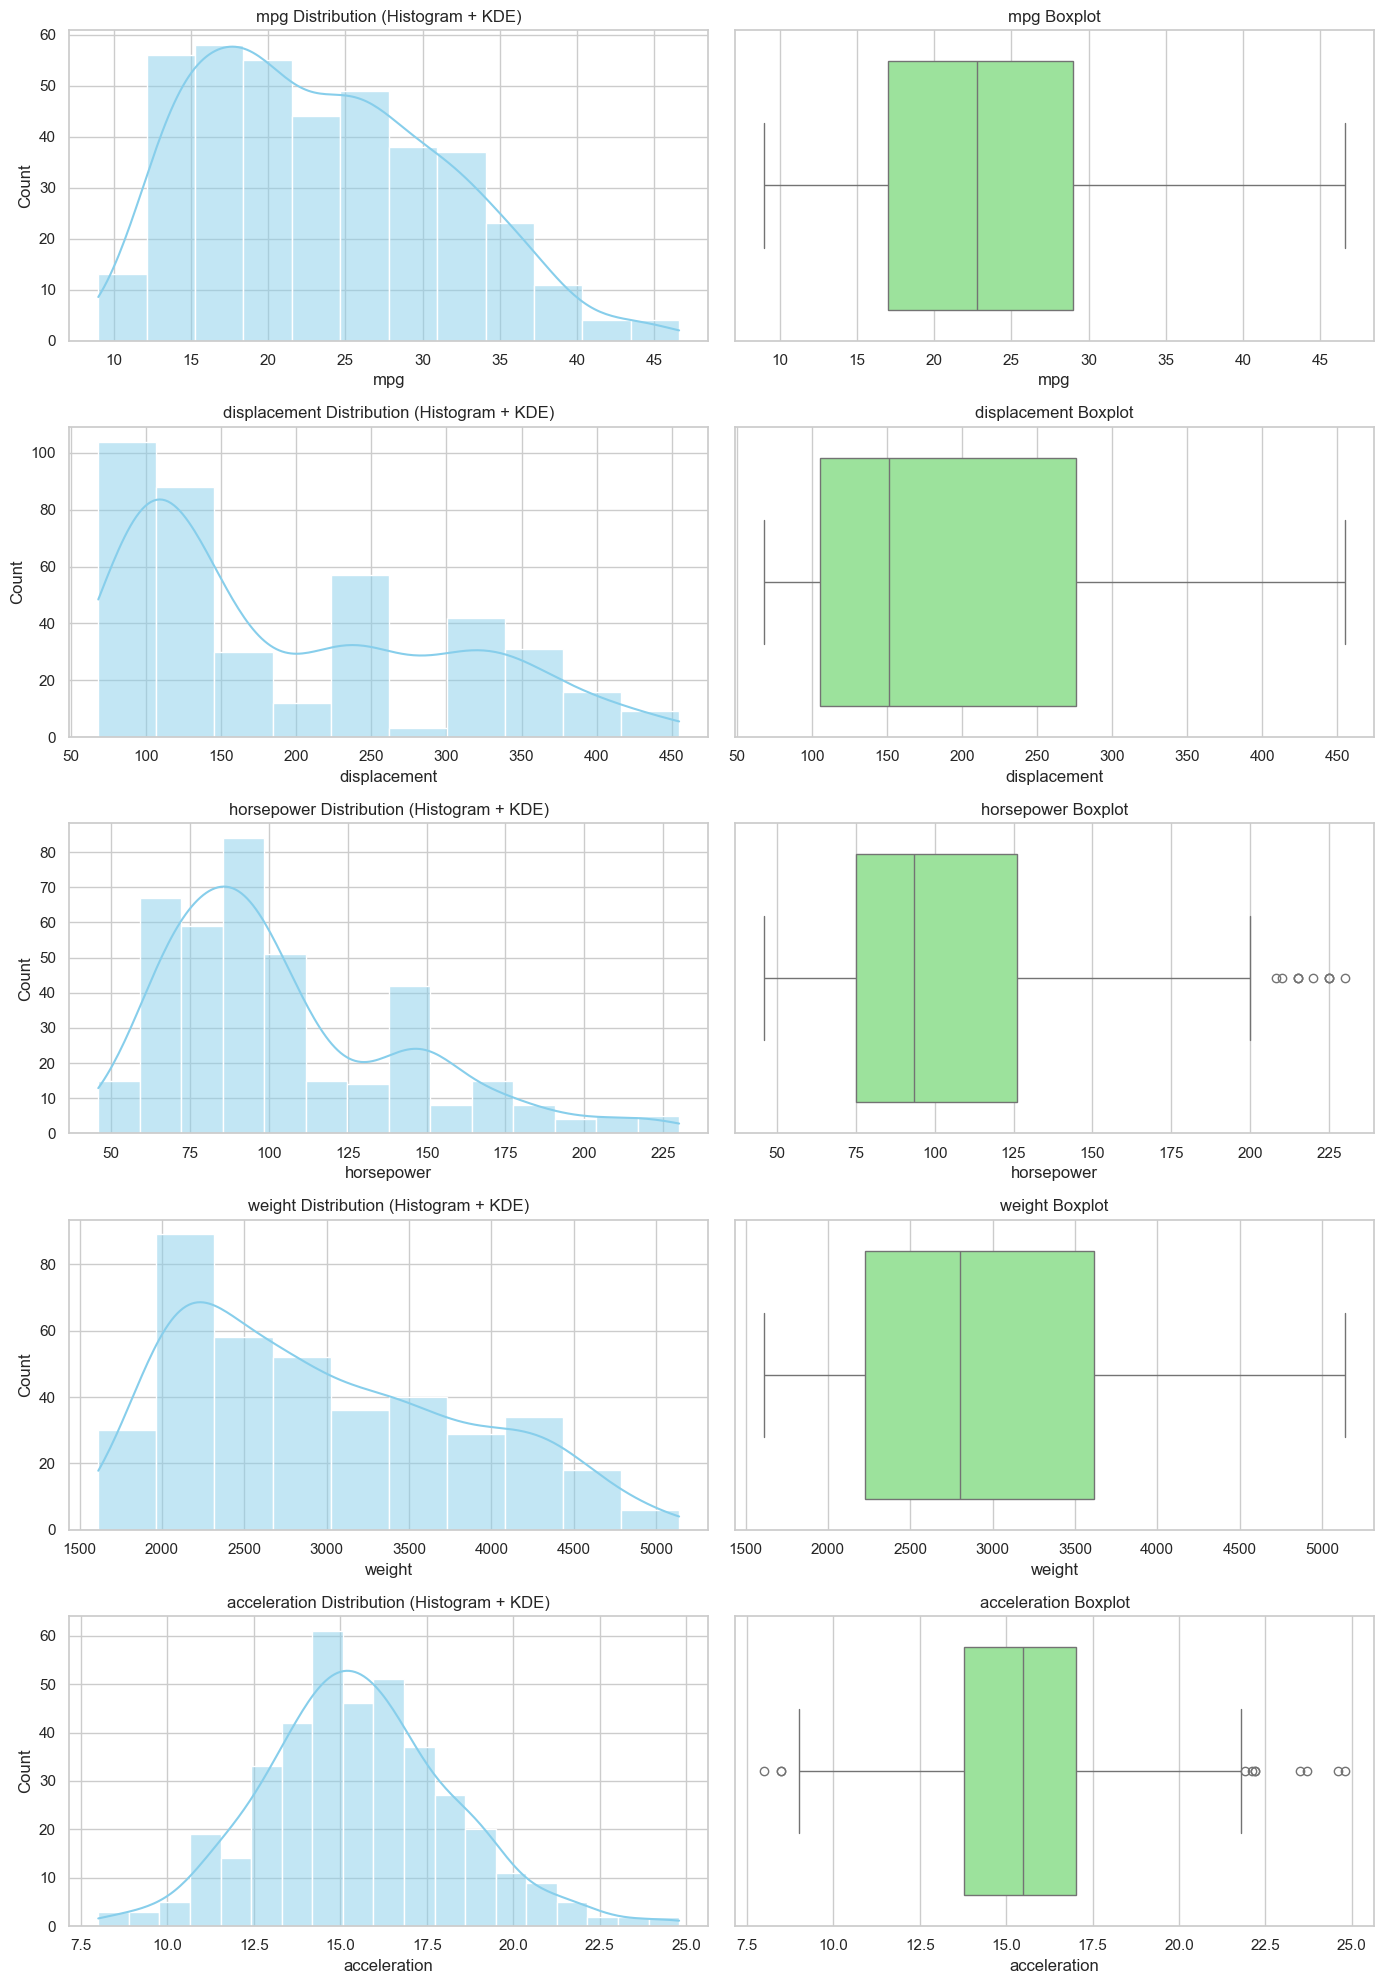

In [15]:
# TODO: For each numerical column plot:
#   (a) Histogram + KDE  (b) Boxplot
# Arrange in a grid (n_cols rows × 2 columns)

n_cols = len(num_cols)
fig, axes = plt.subplots(n_cols, 2, figsize=(14, 4*n_cols))

for i, col in enumerate(num_cols):
    # Histogram + KDE
    sns.histplot(df[col], kde=True, ax=axes[i,0], color='skyblue')
    axes[i,0].set_title(f'{col} Distribution (Histogram + KDE)')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i,1], color='lightgreen')
    axes[i,1].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

In [16]:
# TODO: Write a function tukey_outliers(series) that returns the outlier values
# using the IQR (Tukey) rule: Q1 - 1.5*IQR  and  Q3 + 1.5*IQR
# Then print the outlier count for each numerical column

def tukey_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers

for col in num_cols:
    outliers = tukey_outliers(df[col])
    print(f"{col}: {len(outliers)} outliers")

mpg: 0 outliers
displacement: 0 outliers
horsepower: 10 outliers
weight: 0 outliers
acceleration: 11 outliers


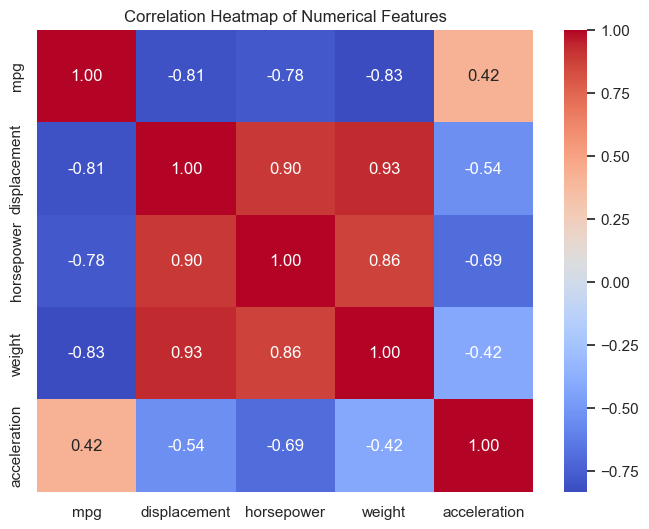

In [17]:
# TODO: Plot a correlation heatmap for all numerical columns (use annot=True)

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

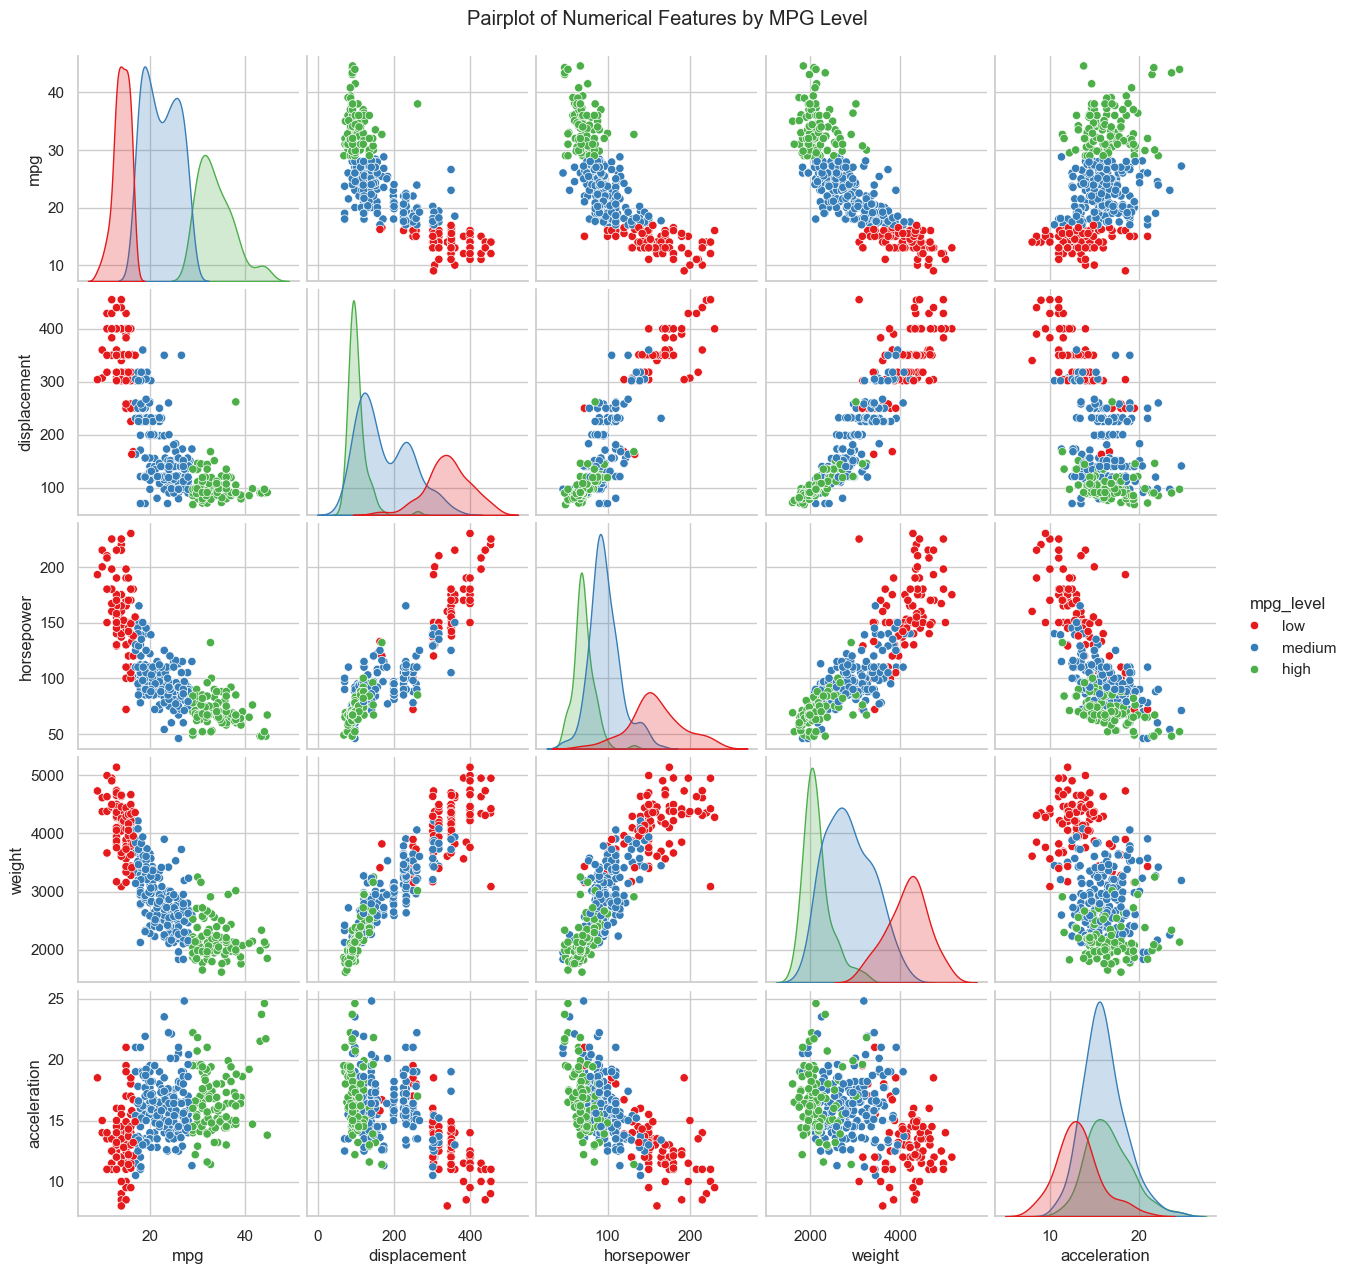

In [18]:
# TODO: Create a pairplot of numerical columns, coloured by mpg_level

sns.pairplot(df[num_cols + ['mpg_level']], hue='mpg_level', palette='Set1', diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features by MPG Level', y=1.02)
plt.show()

**Q5.** Which two numerical features have the strongest negative correlation with mpg?  
**Answer:** weight and displacement

**Q6.** Is the `acceleration` distribution approximately Gaussian? Justify briefly.  
**Answer:** No, it is slightly skewed (right-skewed) as seen from the histogram + KDE plot; it is not perfectly symmetric.

## Task 7 — Numerical vs Categorical

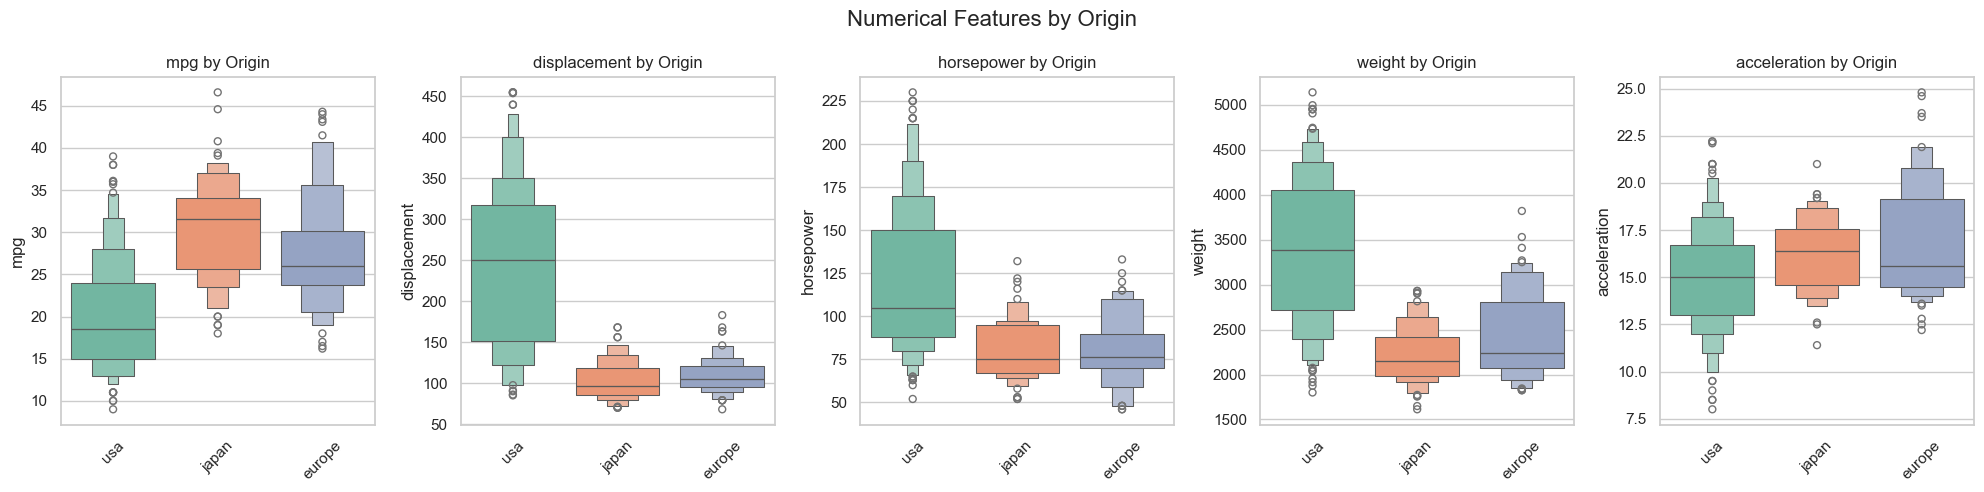

In [19]:
# TODO: Plot boxenplots of all numerical features grouped by 'origin'
# (1 row × 5 column subplot grid)

fig, axes = plt.subplots(1, len(num_cols), figsize=(20,5))

for i, col in enumerate(num_cols):
    sns.boxenplot(
        x='origin', y=col, hue='origin', data=df, ax=axes[i], palette='Set2', 
        dodge=False, legend=False )
    axes[i].set_title(f'{col} by Origin')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Numerical Features by Origin', fontsize=16)
plt.tight_layout()
plt.show()

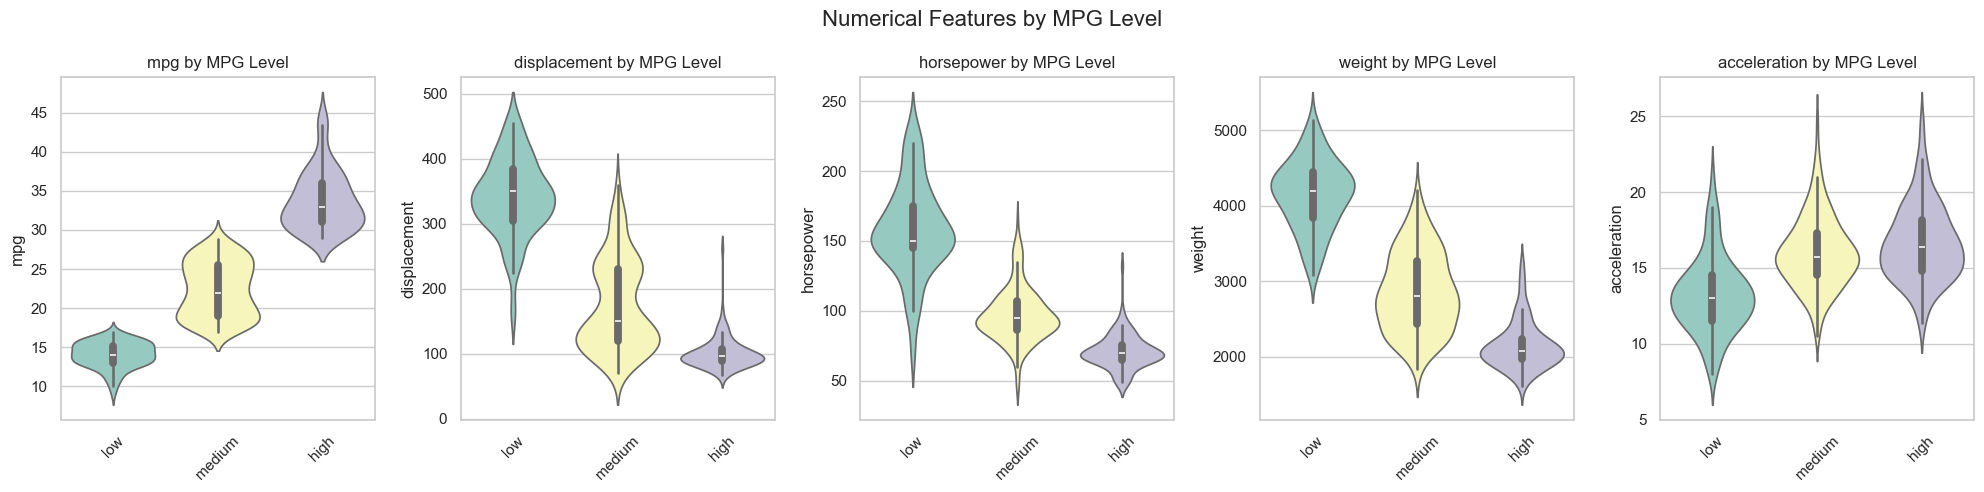

In [20]:
# TODO: Plot violinplots of all numerical features grouped by 'mpg_level'

fig, axes = plt.subplots(1, len(num_cols), figsize=(20,5))

for i, col in enumerate(num_cols):
    sns.violinplot( x='mpg_level', y=col, hue='mpg_level', data=df, ax=axes[i], 
                    palette='Set3', dodge=False, legend=False )
    axes[i].set_title(f'{col} by MPG Level')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Numerical Features by MPG Level', fontsize=16)
plt.tight_layout()
plt.show()

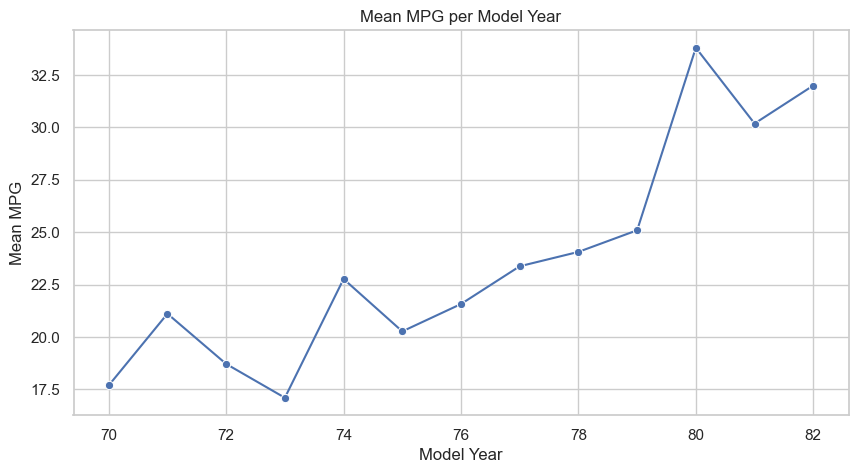

In [21]:
# TODO: Plot a line chart showing mean mpg per model_year

mean_mpg = df.groupby('model_year', observed=False)['mpg'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x='model_year', y='mpg', data=mean_mpg, marker='o', color='b')
plt.title('Mean MPG per Model Year')
plt.xlabel('Model Year')
plt.ylabel('Mean MPG')
plt.grid(True)
plt.show()

**Q7.** On average, which origin produces cars with the lowest mpg?  
**Answer:** The cars from origin with the lowest mean mpg (usually USA in the Auto MPG dataset) produce the lowest mpg on average.

**Q8.** Describe in one sentence how mpg changes as model_year increases.  
**Answer:** On average, mpg increases as model_year increases, showing that newer cars are more fuel-efficient.

## Task 8 — Summary Table
Fill in the table below based on your analysis.

| Feature      | Relationship with MPG                                       | Strength |
| ------------ | ----------------------------------------------------------- | -------- |
| displacement | Negative – higher displacement → lower mpg                  | Strong   |
| horsepower   | Negative – higher horsepower → lower mpg                    | Strong   |
| weight       | Negative – heavier cars → lower mpg                         | Strong   |
| acceleration | Slight positive – faster acceleration → slightly higher mpg | Weak     |
| cylinders    | Negative – more cylinders → lower mpg                       | Strong   |
| origin       | Varies – cars from certain origins (e.g., USA) → lower mpg  | Moderate |
| model_year   | Positive – newer cars → higher mpg                          | Moderate |
